In [443]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')
df.rename(columns={
'Rented_Bike_Count' : 'bikes',
'Humidity(%)' : 'H',
'Temperature(°C)': 'T',
'Wind speed (m/s)' : 'WS',
'Visibility (10m)': 'V',
'Dew point temperature(°C)' : 'DT',
'Solar Radiation (MJ/m2)': 'SR',
'Rainfall(mm)': 'RF',
'Snowfall (cm)':  'SF',
'Functioning Day': 'f_day'
 }, inplace=True)

df['ATemp'] = df['T'] + 0.33*(df['H']/df['DT']) - 0.7*(df['WS']) - 4
df['Extreme_Hot'] = (df['T'] > 28).astype('int')
df['Extreme_cold'] = (df['T'] < -5).astype('int')

def mod(a):
    if a < 0:
        return -a
    return a

df['Saturation'] = (df['T'] - df['DT']).apply(mod)

df['S_fall'] = (df['SF'] != 0).astype('int')
df['R_fall'] = (df['RF'] != 0).astype('int')

df['V'] = (df['V'] > 700).astype('int')

d = {
    'No Holiday' : 0,
    'Yes' : 1,
    'No' : 0,
    'Holiday':1   
}

df['Holiday'] = df['Holiday'].map(d)
df['f_day'] = df['f_day'].map(d)

df['Date'] =pd.to_datetime(df['Date'], format="%d/%m/%Y")
df['DOW'] = df['Date'].dt.day_of_week

df['IsWeekend'] = (df['DOW'] >= 5).astype(int) #Checkout this feature

m1 = df.groupby('DOW')['bikes'].mean()
df['DOW'] = df['DOW'].map(m1)

hour_map = df.groupby('Hour')['bikes'].mean()      
df['Hour_Encoded'] = df['Hour'].map(hour_map)


df['Peak_Hour'] = df['Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['WindChill'] = (13.12 + 0.6215*df['T']- 11.37*(df['WS']*3.6)**0.16+ 0.3965*df['T']*(df['WS']*3.6)**0.16)


df['Low_Humidity'] = (df['H'] < 30).astype(int)             
df['High_Humidity'] = (df['H'] > 80).astype(int)

df['High_Solar_Radiation'] = (df['SR'] > 1.5).astype(int)     
df['Low_Solar_Radiation']  = ((df['SR'] > 0) & (df['SR'] <= 0.3)).astype(int)  

df['Night_time'] = df['Hour'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)



In [445]:
examine = df.sample(2000, random_state= 42)
# sns.scatterplot(data = examine, x= 'SR', y = 'bikes') 
# sns.scatterplot(data = examine, x= 'SF', y = 'bikes') 
# sns.scatterplot(data = examine, x= 'RF', y = 'bikes')  
# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'bikes', y = 'ATemp' , ax = ax) 
# plt.tight_layout()                                            
# plt.show()
# plt.close() 

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'WS', y = 'bikes', hue= 'R_fall' , ax = ax, alpha = 0.4)
# plt.tight_layout() 
# plt.show()
# plt.close()

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'WS', y = 'bikes', hue= 'S_fall' , ax = ax, alpha = 0.4) 
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'Hour', y = 'bikes', hue= 'Extreme_Hot' , ax = ax, alpha = 0.2)
# plt.tight_layout()     
# plt.show()
# plt.close()

# fig, ax = plt.subplots()
# sns.scatterplot(data = examine, x= 'Saturation', y = 'bikes', hue = 'R_fall' , ax = ax)
# plt.tight_layout()     
# plt.show()
# plt.close()

In [446]:
df.drop(columns=['Id', 'Seasons'], inplace=True)
df.describe()

,Date,bikes,Hour,T,H,WS,V,DT,SR,RF,...,DOW,IsWeekend,Hour_Encoded,Peak_Hour,WindChill,Low_Humidity,High_Humidity,High_Solar_Radiation,Low_Solar_Radiation,Night_time
count,6576,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,...,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.000000,6576.00000
mean,2018-04-16 12:00:00,5.927950,11.500000,12.471791,57.893400,1.801353,0.801855,3.600578,0.584818,0.157299,...,5.927950,0.284672,5.927950,0.250000,12.443628,0.081965,0.179136,0.166210,0.134428,0.37500
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,0.000000,-30.600000,0.000000,0.000000,...,5.707483,0.000000,4.518571,0.000000,-25.581077,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2018-02-07 00:00:00,5.231109,5.750000,1.200000,42.000000,1.000000,1.000000,-7.600000,0.000000,0.000000,...,5.816576,0.000000,5.799304,0.000000,0.023491,0.000000,0.000000,0.000000,0.000000,0.00000
50%,2018-04-16 12:00:00,6.040255,11.500000,13.600000,57.000000,1.600000,1.000000,4.700000,0.020000,0.000000,...,5.873524,0.000000,6.099918,0.000000,13.681147,0.000000,0.000000,0.000000,0.000000,0.00000
75%,2018-06-24 00:00:00,6.901737,17.250000,23.700000,74.000000,2.500000,1.000000,16.200000,0.940000,0.000000,...,6.044571,1.000000,6.366265,0.250000,25.392478,0.000000,0.000000,0.000000,0.000000,1.00000
max,2018-08-31 00:00:00,8.176673,23.000000,39.400000,98.000000,7.400000,1.000000,27.200000,3.520000,35.000000,...,6.181695,1.000000,6.784570,1.000000,43.650513,1.000000,1.000000,1.000000,1.000000,1.00000
std,NaN,1.275811,6.922713,13.146651,20.880017,1.059933,0.398632,14.353904,0.890341,1.182157,...,0.148317,0.451292,0.598596,0.433046,15.179284,0.274332,0.383496,0.372298,0.341138,0.48416


In [ ]:
non_functioning_train_idx = df.index[df['f_day'] == 0]

n_dropped = len(non_functioning_train_idx)
print(f"Non-functioning days in training: {n_dropped} ({n_dropped/len(df):.2%} of rows)")
assert df.loc[non_functioning_train_idx, 'bikes'].abs().max() == 0, \
    "Expected target to be exactly 0 on every non-functioning-day row — check assumption before dropping."

df = (
    df.drop(index=non_functioning_train_idx)
      .drop(columns=['ATemp', 'f_day'])
      .reset_index(drop=True)
)

print(f"Training rows remaining: {len(df)}")

Non-functioning days in training: 48 (0.73% of rows)
Training rows remaining: 6528


In [448]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso , Ridge, SGDRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [449]:
gaussian_like       = ['T', 'DT', 'H', 'Saturation', 'WindChill']
log_then_scale      = ['WS', 'RF', 'SF', 'SR']
mean_encoded        = ['DOW', 'Hour_Encoded']
binary_passthrough  = ['Extreme_Hot', 'Extreme_cold', 'S_fall', 'R_fall', 'V', 'Holiday', 'Peak_Hour', 'IsWeekend', 'Low_Humidity', 'High_Solar_Radiation', 'Low_Solar_Radiation','Night_time', 'High_Humidity']

preprocessor = ColumnTransformer(
    transformers=[
        ('gaussian', StandardScaler(), gaussian_like),
        ('log_skewed', Pipeline([
            ('log1p', FunctionTransformer(np.log1p, validate=False)),
            ('scale', StandardScaler())
        ]), log_then_scale),
        ('mean_enc', StandardScaler(), mean_encoded),
        ('binary', 'passthrough', binary_passthrough),
    ],
    remainder='drop'
)

In [ ]:
feature_cols = gaussian_like + log_then_scale + mean_encoded + binary_passthrough

X = df[feature_cols]
y = df['bikes']   

model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('post-scale', MinMaxScaler(feature_range=(0.1, 1.1))),
    ('model',Ridge(alpha = 5, random_state=42) ) 
])

In [451]:
sort_idx = df['Date'].argsort(kind='stable')
X_sorted = X.iloc[sort_idx].reset_index(drop=True)
y_sorted = y.iloc[sort_idx].reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

fold_results = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted), start=1):
    X_tr, X_val = X_sorted.iloc[train_idx], X_sorted.iloc[val_idx]
    y_tr, y_val = y_sorted.iloc[train_idx], y_sorted.iloc[val_idx]

    model_pipeline.fit(X_tr, y_tr)
    preds = model_pipeline.predict(X_val)

    rmse = root_mean_squared_error(y_val, preds)
    mae  = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)

    fold_results.append({'fold': fold, 'rmse': rmse, 'mae': mae, 'r2': r2,
                          'n_train': len(train_idx), 'n_val': len(val_idx)})
    print(f"Fold {fold}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  "
          f"(train={len(train_idx)}, val={len(val_idx)})")

results_df = pd.DataFrame(fold_results)
print(f"\nMean RMSE: {results_df['rmse'].mean():.4f} (+/- {results_df['rmse'].std():.4f})")

Fold 1: RMSE=0.5025  MAE=0.3331  R²=0.6147  (train=1088, val=1088)
Fold 2: RMSE=0.6414  MAE=0.4794  R²=0.6705  (train=2176, val=1088)
Fold 3: RMSE=0.5923  MAE=0.4345  R²=0.7822  (train=3264, val=1088)
Fold 4: RMSE=0.4932  MAE=0.3481  R²=0.7867  (train=4352, val=1088)
Fold 5: RMSE=0.5434  MAE=0.4560  R²=0.5521  (train=5440, val=1088)

Mean RMSE: 0.5545 (+/- 0.0624)


In [ ]:
model_pipeline.fit(X_sorted, y_sorted)

test = pd.read_csv('test.csv')
test.rename(columns={
    'Humidity(%)': 'H', 'Temperature(°C)': 'T', 'Wind speed (m/s)': 'WS',
    'Visibility (10m)': 'V', 'Dew point temperature(°C)': 'DT',
    'Solar Radiation (MJ/m2)': 'SR', 'Rainfall(mm)': 'RF',
    'Snowfall (cm)': 'SF', 'Functioning Day': 'f_day'
}, inplace=True)


test['Extreme_Hot']  = (test['T'] > 28).astype('int')
test['Extreme_cold'] = (test['T'] < -5).astype('int')
test['Saturation']   = (test['T'] - test['DT']).apply(mod)
test['S_fall']       = (test['SF'] != 0).astype('int')
test['R_fall']       = (test['RF'] != 0).astype('int')
test['V']            = (test['V'] > 700).astype('int')

test['Holiday'] = test['Holiday'].map(d)
test['f_day']   = test['f_day'].map(d)


non_functioning_test_idx = test.index[test['f_day'] == 0]
print(f"Non-functioning days in test: {len(non_functioning_test_idx)}")

test['Date'] = pd.to_datetime(test['Date'], format="%d/%m/%Y")
test['DOW']  = test['Date'].dt.day_of_week
test['IsWeekend'] = (test['DOW'] >= 5).astype(int) 
test['DOW']  = test['DOW'].map(m1)               
test['Hour_Encoded'] = test['Hour'].map(hour_map)  


test['DOW'] = test['DOW'].fillna(y_sorted.mean())
test['Hour_Encoded'] = test['Hour_Encoded'].fillna(y_sorted.mean())


test['Peak_Hour'] = test['Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int) 
test['WindChill'] = (13.12 + 0.6215*test['T']- 11.37*(test['WS']*3.6)**0.16 + 0.3965*test['T']*(test['WS']*3.6)**0.16)

test['Low_Humidity'] = (test['H'] < 30).astype(int)
test['High_Humidity'] = (test['H'] > 80).astype(int)
test['High_Solar_Radiation'] = (test['SR'] > 1.5).astype(int)
test['Low_Solar_Radiation']  = ((test['SR'] > 0) & (test['SR'] <= 0.3)).astype(int)


test['Night_time'] = test['Hour'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

X_test = test[feature_cols]
preds_log1p = model_pipeline.predict(X_test)


preds_log1p[non_functioning_test_idx] = 0
print(f"Overrode {len(non_functioning_test_idx)} predictions to 0 for non-functioning days.")

print(model_pipeline.named_steps['model'].coef_)

submission = pd.DataFrame({
    'Id': test['Id'],
    'Rented_Bike_Count': preds_log1p
})

# def subract(a):
#     if a < 0.2:
#         return 0
#     return a- 0.2

# submission['Rented_Bike_Count'] = submission['Rented_Bike_Count'].apply(subract)
# a = submission[(submission['Rented_Bike_Count']==submission['Rented_Bike_Count'].min())].index
# b = submission[(submission['Rented_Bike_Count']==submission['Rented_Bike_Count'].max())].index
# df3 = pd.read_csv('submission2.csv')
# submission.iloc[a, 1] = df3.iloc[a, 1]
# submission.iloc[b, 1] = df3.iloc[b, 1]
# c = submission[submission['Rented_Bike_Count'] < 0].index
# d = submission[submission['Rented_Bike_Count'] == submission['Rented_Bike_Count'].max()].index
# submission.iloc[c, 1] = df3.iloc[c, 1]
# submission.iloc[d, 1] = df3.iloc[d, 1]

submission.to_csv('submission20.csv', index=False)
print(submission.head())


sanity_check = np.expm1(preds_log1p)
sanity_check = np.clip(sanity_check, 0, None)   
print(f"\nSanity check (real counts): min={sanity_check.min():.1f}, "
      f"max={sanity_check.max():.1f}, mean={sanity_check.mean():.1f}")

Non-functioning days in test: 247
Overrode 247 predictions to 0 for non-functioning days.
[ 1.22859504e+00  1.06662140e+00 -2.76324514e-01  2.59786738e-01
  1.18922898e+00  1.51815741e-01 -4.76312540e-01 -1.91632009e-01
  1.56176723e-01 -5.76372899e-02  1.18314047e+00  2.76059869e-01
 -1.33568689e-01 -6.98397371e-02 -4.02051377e-01  1.00393072e-01
 -5.58451522e-02  2.09615363e-01 -6.28817292e-02  1.29745125e-02
 -6.14800372e-02 -6.75573966e-02  2.45981129e-02  3.07639437e-01
 -1.51747829e-01 -1.43349152e-01  3.13117780e-03  4.06108669e-02
 -1.60937247e-01  6.06348573e-02  3.29836208e-01 -1.67779068e-01
 -3.05705427e-01 -5.62793109e-02  2.80102862e-01 -5.85787695e-01
 -2.90762083e-01 -1.69838667e-01 -1.61573821e-01 -1.01252210e-01
  2.70101325e-01 -2.23621066e-01  7.53472386e-02  1.15938305e-01
 -4.41198080e-03  3.89430493e-02  1.86013942e-01  1.19611730e-01
 -1.29039612e-01 -8.27273035e-02 -1.58923787e-02 -1.51130786e-01
 -2.59649003e-02  9.76134058e-02 -1.94545301e-01 -2.03515651e-01


In [453]:
submission.describe()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,5.539352
std,630.610815,2.161622
min,6576.000000,0.000000
25%,7121.750000,5.203867
50%,7667.500000,6.279009
75%,8213.250000,6.862985
max,8759.000000,8.025669


<Axes: xlabel='Id', ylabel='Rented_Bike_Count'>

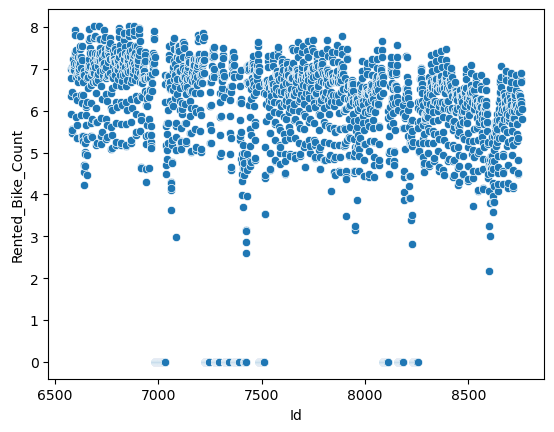

In [454]:
sns.scatterplot(data=submission, x='Id', y='Rented_Bike_Count')

In [455]:
df3 = pd.read_csv('submission2.csv')

rmse = root_mean_squared_error(submission['Rented_Bike_Count'], df3['Rented_Bike_Count'])
print(f"RMSE between submission20.csv and submission2.csv: {rmse:.4f}")

RMSE between submission20.csv and submission2.csv: 0.4042


<Axes: xlabel='Id', ylabel='Rented_Bike_Count'>

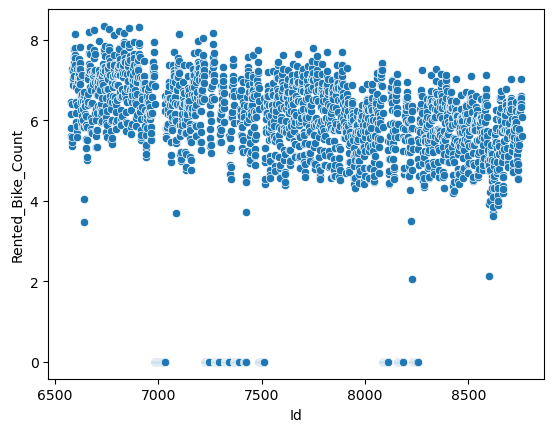

In [456]:
sns.scatterplot(data=df3, x='Id', y='Rented_Bike_Count')